### CNN Basic Neural Net for Handwritten Image Data MNIST DATABASE

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import utils
import pandas as pd
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.preprocessing import image

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
single_image= X_train[0]

In [6]:
single_image.shape

(28, 28)

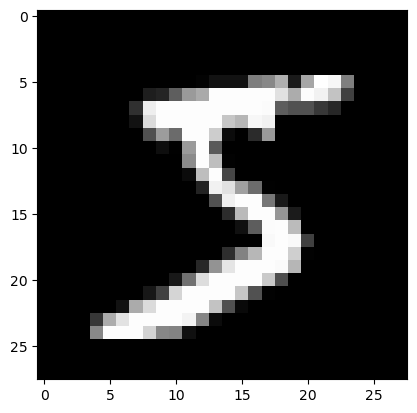

In [7]:
plt.imshow(single_image,cmap='gray')

In [8]:
y_train.shape

(60000,)

In [9]:
X_train.min()

np.uint8(0)

In [10]:
X_train.max()

np.uint8(255)

In [11]:
X_train_scaled = X_train/255.0
X_test_scaled = X_test/255.0

In [12]:
X_train_scaled.min()

np.float64(0.0)

In [13]:
X_train_scaled.max()

np.float64(1.0)

In [14]:
y_train[0]

np.uint8(5)

In [15]:
y_train_onehot = utils.to_categorical(y_train,10)
y_test_onehot = utils.to_categorical(y_test,10)

In [16]:
type(y_train_onehot)

numpy.ndarray

In [17]:
y_train_onehot.shape

(60000, 10)

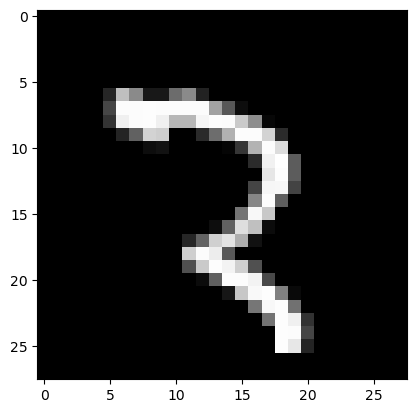

In [18]:
single_image = X_train[500]
plt.imshow(single_image,cmap='gray')

In [19]:
y_train_onehot[500]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [20]:
X_train_scaled = X_train_scaled.reshape(-1,28,28,1)
X_test_scaled = X_test_scaled.reshape(-1,28,28,1)

In [21]:
model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Choose the appropriate parameters
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [24]:
model.fit(X_train_scaled ,y_train_onehot, epochs=5,
          batch_size=64,
          validation_data=(X_test_scaled,y_test_onehot))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9502 - loss: 0.1621 - val_accuracy: 0.9836 - val_loss: 0.0517
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9846 - loss: 0.0496 - val_accuracy: 0.9837 - val_loss: 0.0487
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9895 - loss: 0.0347 - val_accuracy: 0.9896 - val_loss: 0.0298
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9918 - loss: 0.0248 - val_accuracy: 0.9903 - val_loss: 0.0288
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9943 - loss: 0.0185 - val_accuracy: 0.9893 - val_loss: 0.0310


In [25]:
metrics = pd.DataFrame(model.history.history)

In [26]:
metrics.head()

,accuracy,loss,val_accuracy,val_loss
0,0.950200,0.162093,0.9836,0.051676
1,0.984600,0.049629,0.9837,0.048665
2,0.989483,0.034715,0.9896,0.029844
3,0.991783,0.024808,0.9903,0.028815
4,0.994317,0.018469,0.9893,0.030978


<Axes: >

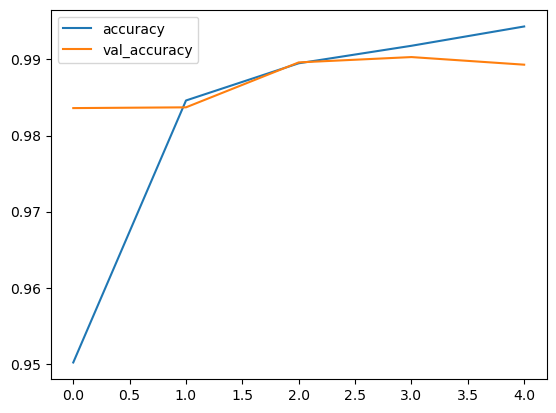

In [27]:
metrics[['accuracy','val_accuracy']].plot()

<Axes: >

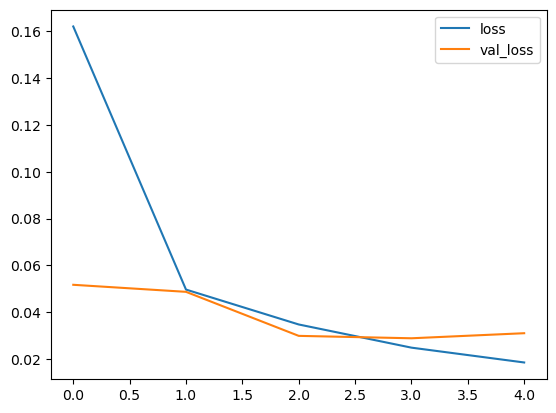

In [28]:
metrics[['loss','val_loss']].plot()

In [29]:
x_test_predictions = np.argmax(model.predict(X_test_scaled), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


In [30]:
print(confusion_matrix(y_test,x_test_predictions))

[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1134    0    0    1    0    0    0    0    0]
 [   2    1 1017    4    2    0    0    4    2    0]
 [   1    0    0 1003    0    5    0    0    1    0]
 [   0    0    0    0  975    0    2    0    1    4]
 [   1    0    0    4    0  886    1    0    0    0]
 [   4    2    0    0    1    9  941    0    1    0]
 [   0    4    5    0    0    0    0 1016    1    2]
 [   7    1    2    1    0    4    0    0  957    2]
 [   0    3    0    0    4    8    0    4    4  986]]


In [31]:
print(classification_report(y_test,x_test_predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.97      0.99      0.98       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



**Prediction for a single input**



Displaying image at index: 7710
Actual label: 2


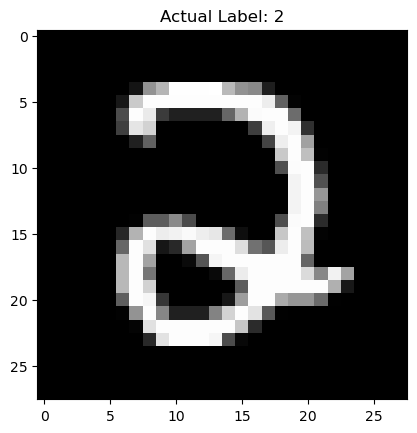

In [32]:
random_index = np.random.randint(0, len(X_test_scaled))
single_test_image = X_test_scaled[random_index]
actual_label = np.argmax(y_test_onehot[random_index])

print(f"Displaying image at index: {random_index}")
print(f"Actual label: {actual_label}")

plt.imshow(single_test_image.reshape(28,28), cmap='gray')
plt.title(f"Actual Label: {actual_label}")
plt.show()

Now that we have a single image, let's use the trained model to predict its digit.

In [33]:
predicted_probabilities = model.predict(single_test_image.reshape(1,28,28,1))
predicted_label = np.argmax(predicted_probabilities)

print(f"Predicted label: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted label: 2


Displaying MNIST image at index: 4120
Actual label: 3


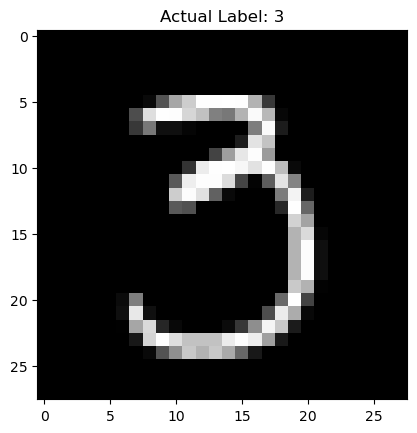

In [34]:
random_index = np.random.randint(0, len(X_test_scaled))
single_test_image_mnist = X_test_scaled[random_index]
actual_label_mnist = np.argmax(y_test_onehot[random_index])

print(f"Displaying MNIST image at index: {random_index}")
print(f"Actual label: {actual_label_mnist}")

plt.imshow(single_test_image_mnist.reshape(28,28), cmap='gray')
plt.title(f"Actual Label: {actual_label_mnist}")
plt.show()

Now, let's use the trained model to predict the digit for this MNIST image.

In [35]:
predicted_probabilities_mnist = model.predict(single_test_image_mnist.reshape(1,28,28,1))
predicted_label_mnist = np.argmax(predicted_probabilities_mnist)

print(f"Predicted label: {predicted_label_mnist}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted label: 3


In [36]:
x_test_predictions = np.argmax(model.predict(X_test_scaled), axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_test,x_test_predictions))

print("\nClassification Report:")
print(classification_report(y_test,x_test_predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1134    0    0    1    0    0    0    0    0]
 [   2    1 1017    4    2    0    0    4    2    0]
 [   1    0    0 1003    0    5    0    0    1    0]
 [   0    0    0    0  975    0    2    0    1    4]
 [   1    0    0    4    0  886    1    0    0    0]
 [   4    2    0    0    1    9  941    0    1    0]
 [   0    4    5    0    0    0    0 1016    1    2]
 [   7    1    2    1    0    4    0    0  957    2]
 [   0    3    0    0    4    8    0    4    4  986]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.97      0.99      0.98       892
       

### Visualizing Predictions on Test Images

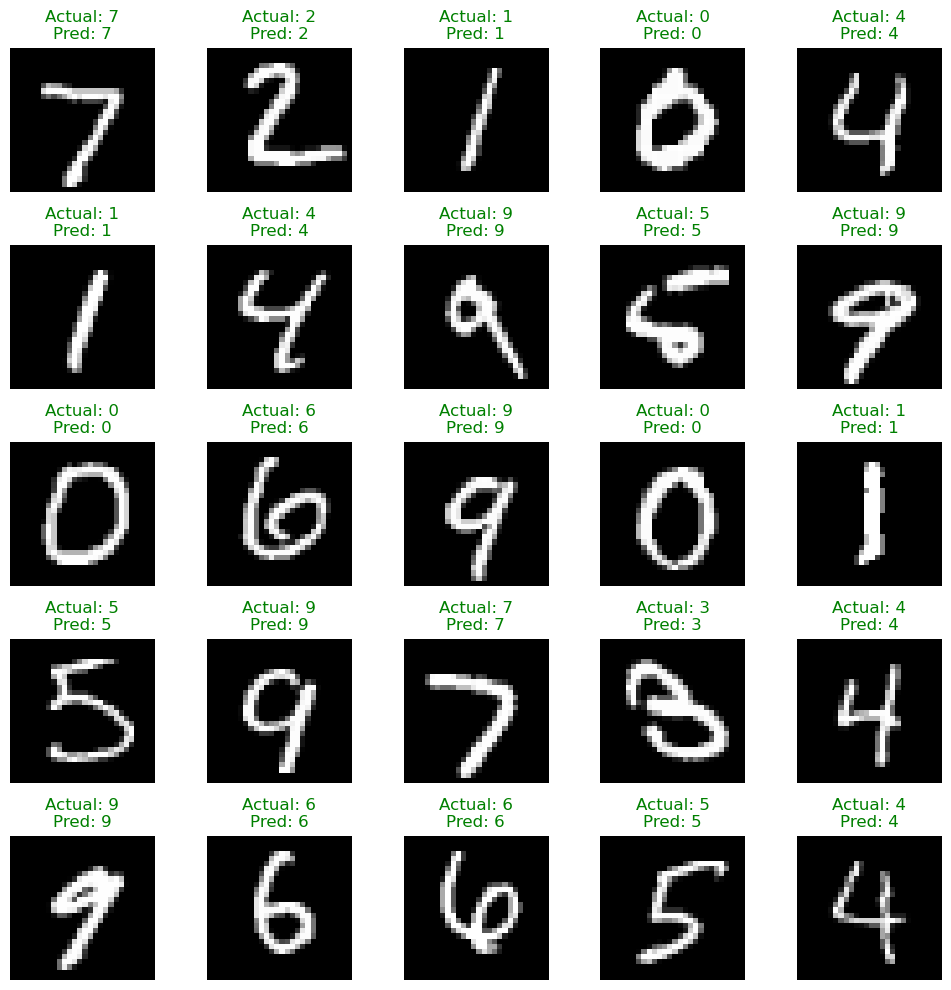

In [37]:
import matplotlib.pyplot as plt

# Display a subset of the test images with their actual and predicted labels
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.ravel()

for i in np.arange(0, 25): # Display first 25 images
    axes[i].imshow(X_test_scaled[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Actual: {y_test[i]}\nPred: {x_test_predictions[i]}",
                      color='green' if y_test[i] == x_test_predictions[i] else 'red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Incorrect Predictions

Total incorrect predictions: 107
Total correct predictions: 9893


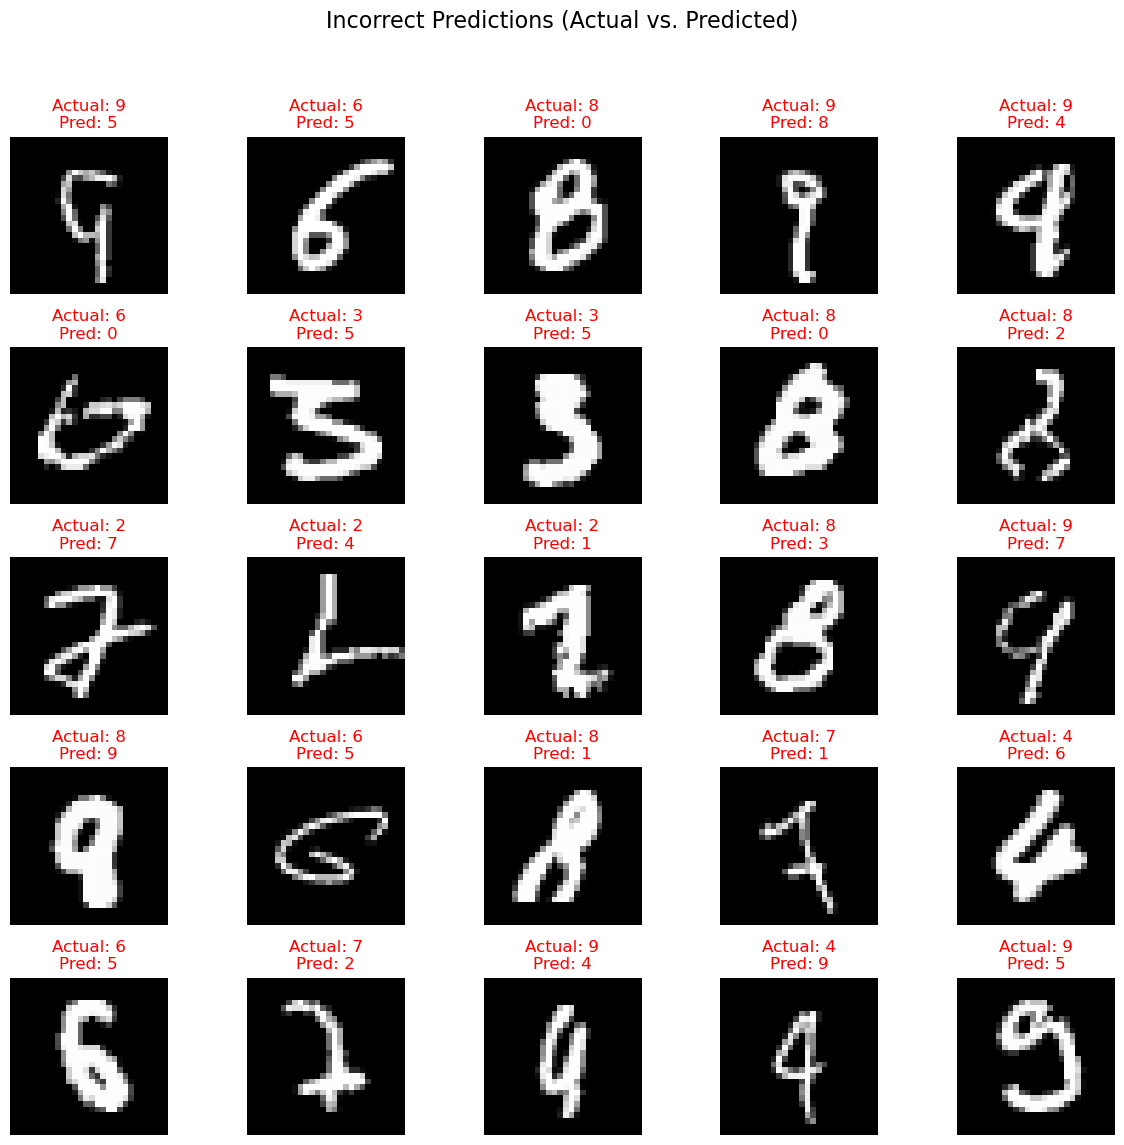

In [38]:
import matplotlib.pyplot as plt

# Find indices of incorrect predictions
incorrect_indices = np.where(y_test != x_test_predictions)[0]

print(f"Total incorrect predictions: {len(incorrect_indices)}")

correct_predictions_count = len(y_test) - len(incorrect_indices)
print(f"Total correct predictions: {correct_predictions_count}")

# Display a subset of the incorrectly predicted images
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.ravel()

# Display up to 25 incorrect predictions, or fewer if there aren't that many
for i, idx in enumerate(incorrect_indices[:25]):
    axes[i].imshow(X_test_scaled[idx].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Actual: {y_test[idx]}\nPred: {x_test_predictions[idx]}",
                      color='red')
    axes[i].axis('off')

# Hide any unused subplots if less than 25 incorrect predictions are displayed
for j in range(i + 1, 25):
    fig.delaxes(axes[j])

plt.suptitle('Incorrect Predictions (Actual vs. Predicted)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()